In [6]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [7]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

In [8]:
print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [9]:
nav["date"] = pd.to_datetime(nav["date"])

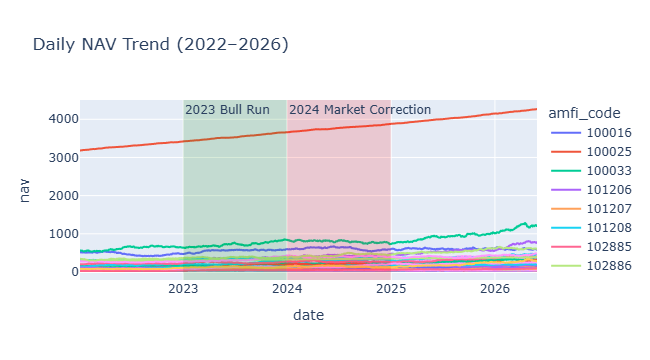

In [10]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Save the interactive chart
fig.write_html("../charts/nav_trend.html")

# Display the chart
fig.show()

## Insight 1

The daily NAV of most mutual fund schemes showed an overall upward trend from 2022 to 2025. A strong rise was observed during 2023, while 2024 experienced periods of market correction before recovering again.

In [13]:
# Chart 2 - AUM Growth

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

In [14]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


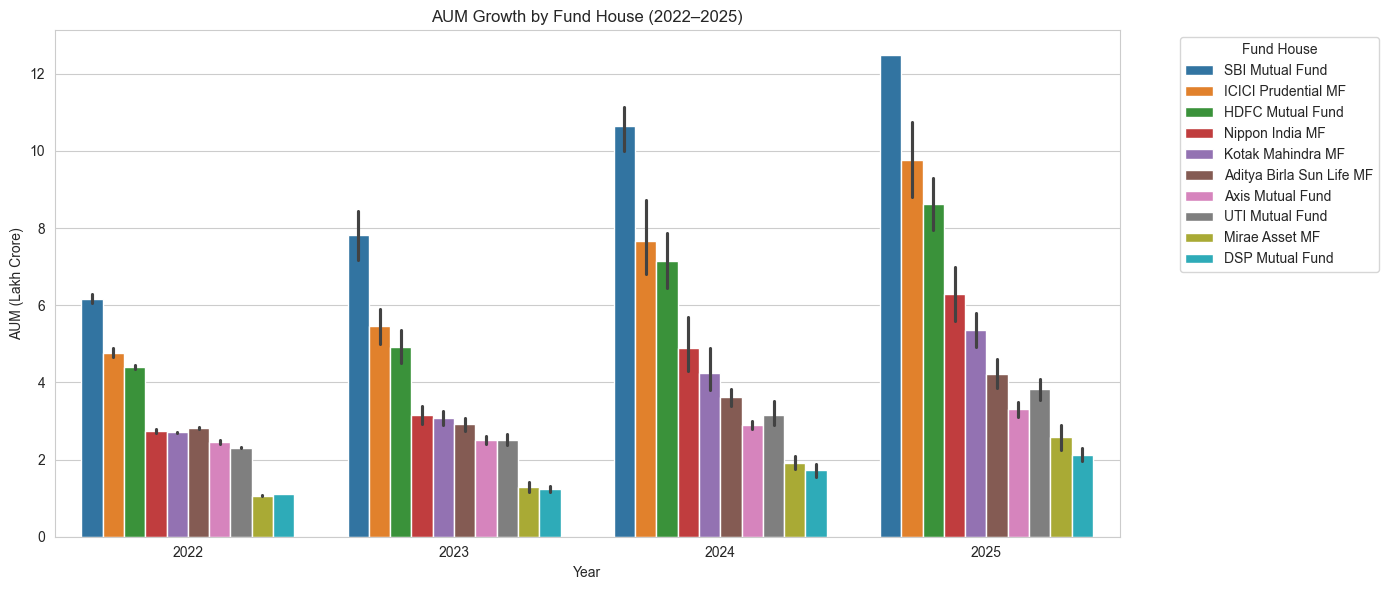

In [15]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.savefig("../charts/aum_growth.png", dpi=300)

plt.show()

## Insight 2

Assets Under Management (AUM) increased consistently from 2022 to 2025 across major fund houses. SBI Mutual Fund maintained the highest AUM during this period, indicating strong investor confidence and market leadership.

In [19]:
# Chart 3 - SIP Inflow Trend

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

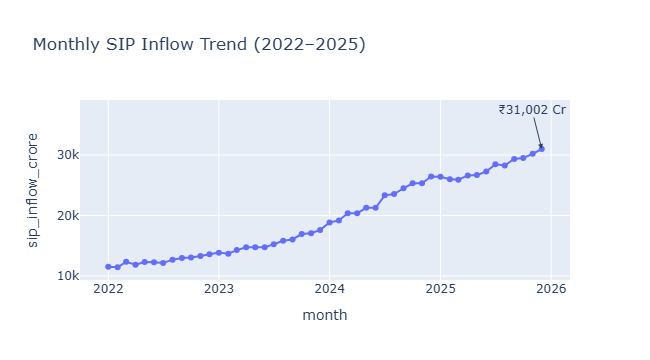

In [20]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ay=-40
)

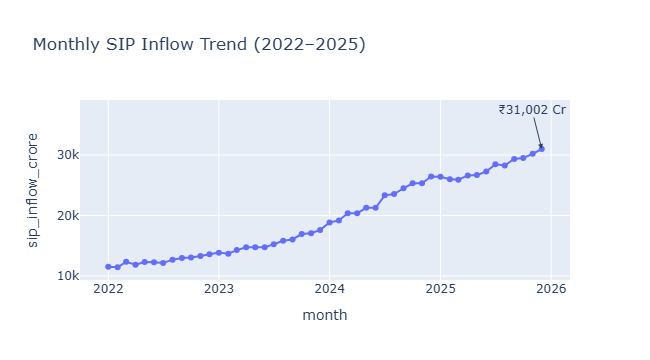

In [21]:
fig.write_html("../charts/sip_trend.html")

fig.show()

## Insight 3

Monthly SIP inflows showed a consistent upward trend between 2022 and 2025. The highest monthly SIP inflow was recorded at the end of the period, indicating increasing retail investor participation in mutual funds.

In [22]:
# Chart 4 - Category Inflow Heatmap

category = pd.read_csv("../data/processed/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [23]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [24]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


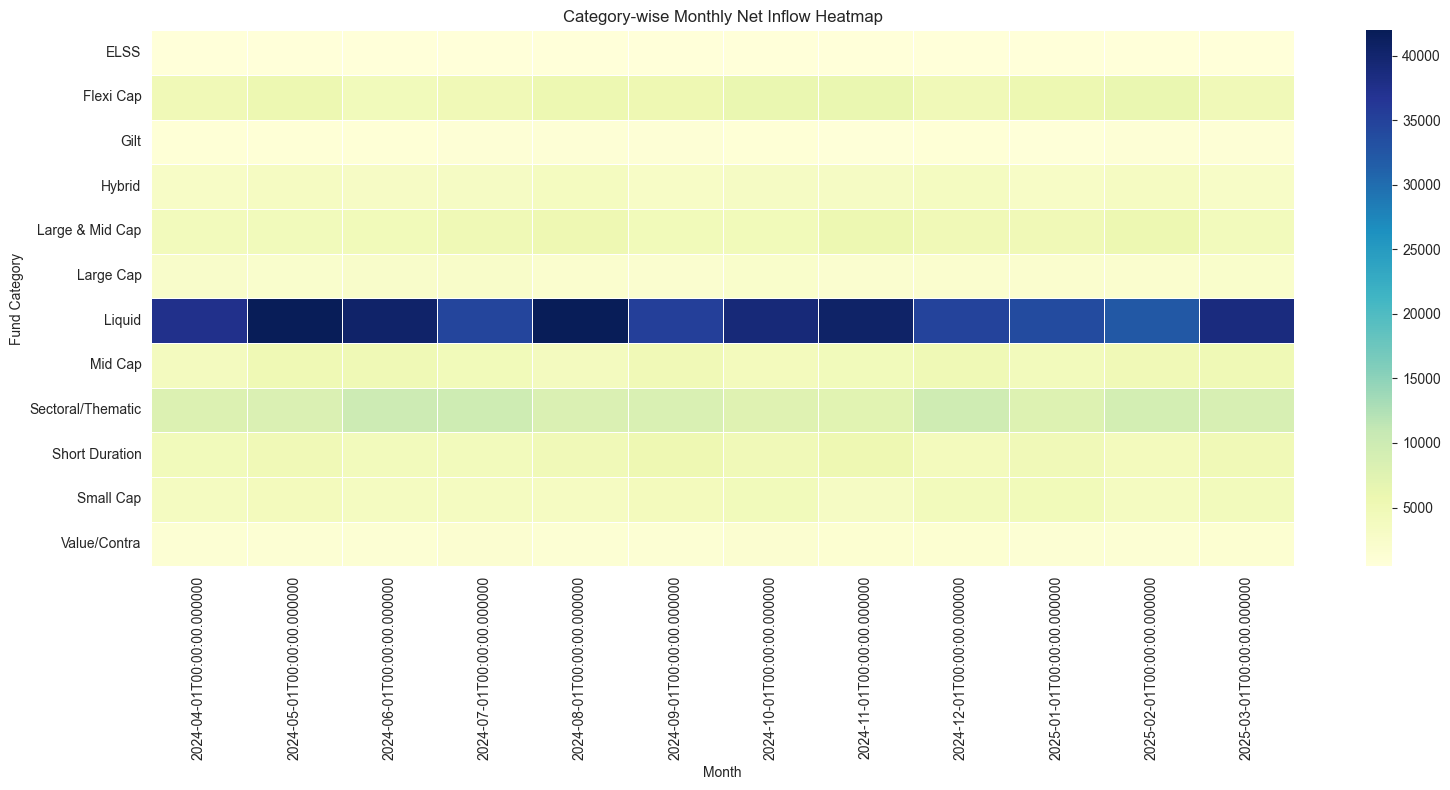

In [25]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../charts/category_heatmap.png", dpi=300)

plt.show()

## Insight 4

Monthly net inflows varied across mutual fund categories. Equity-oriented categories generally attracted higher inflows, while some categories experienced temporary outflows during market corrections.

In [26]:
# Chart 5 - Age Group Distribution

investor = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [27]:
age_data = investor["age_group"].value_counts()

age_data

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

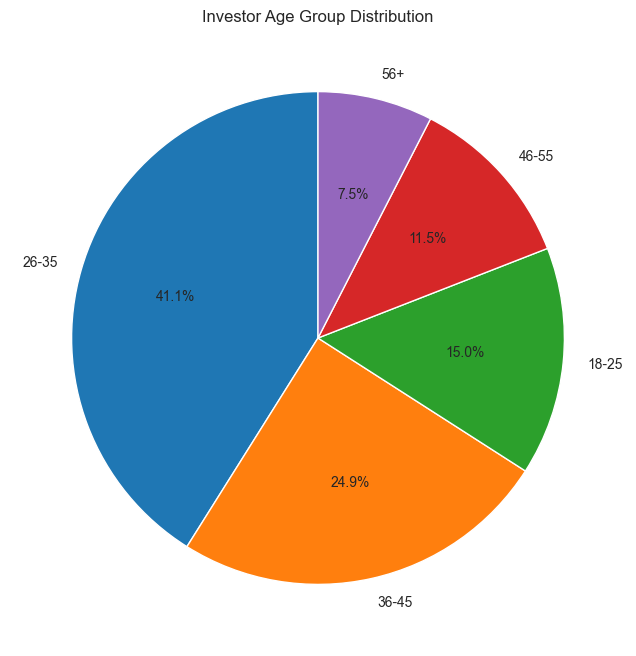

In [28]:
plt.figure(figsize=(8,8))

plt.pie(
    age_data,
    labels=age_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("../charts/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 5

The investor base is distributed across multiple age groups. The largest age group contributes the highest share of mutual fund transactions, indicating strong participation from that segment.

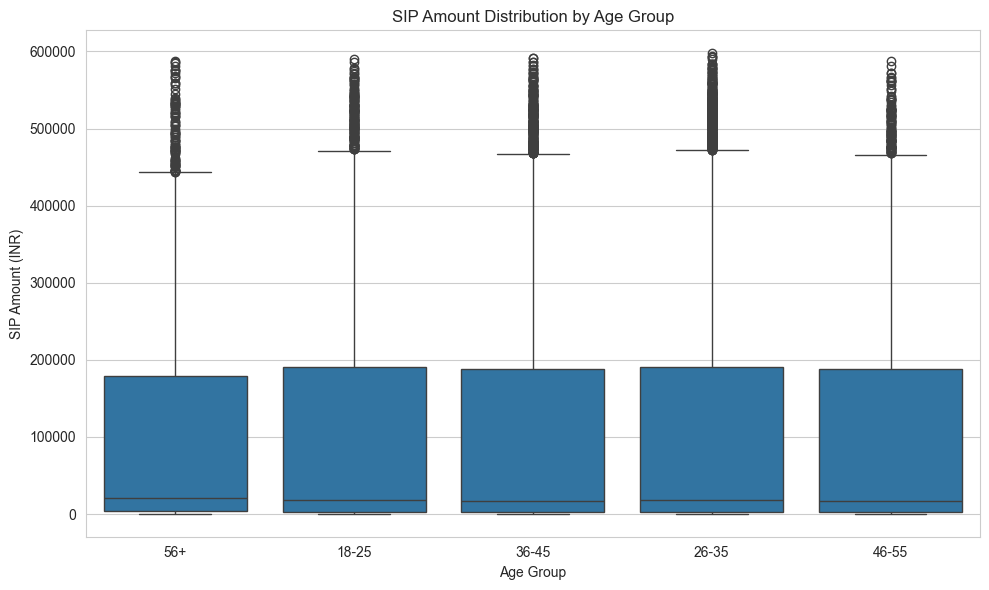

In [29]:
# Chart 6 - SIP Amount by Age Group

plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.tight_layout()

plt.savefig("../charts/sip_boxplot_age.png", dpi=300)

plt.show()

## Insight 6

The SIP investment amount varies across different age groups. Some age groups show a wider spread of investment values, indicating differences in investment behavior.

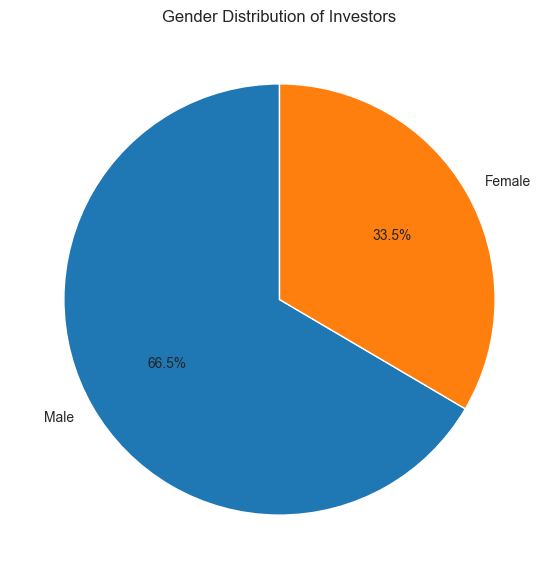

In [30]:
# Chart 7 - Gender Distribution

gender_data = investor["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_data,
    labels=gender_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig("../charts/gender_distribution.png", dpi=300)

plt.show()

## Insight 7

The investor population includes participation from different genders. The distribution provides an overview of investor diversity within the dataset.

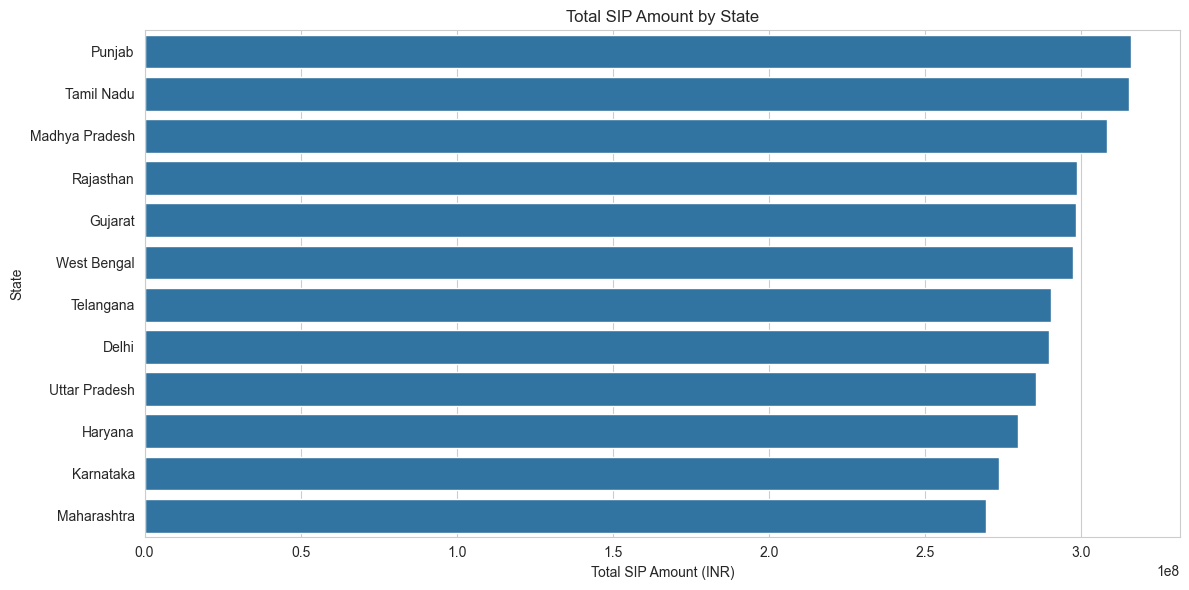

In [31]:
# Chart 8 - State-wise SIP Amount

state_data = investor.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../charts/state_sip_amount.png", dpi=300)

plt.show()

## Insight 8

Some states contribute significantly higher SIP investment amounts than others, indicating regional differences in mutual fund participation.

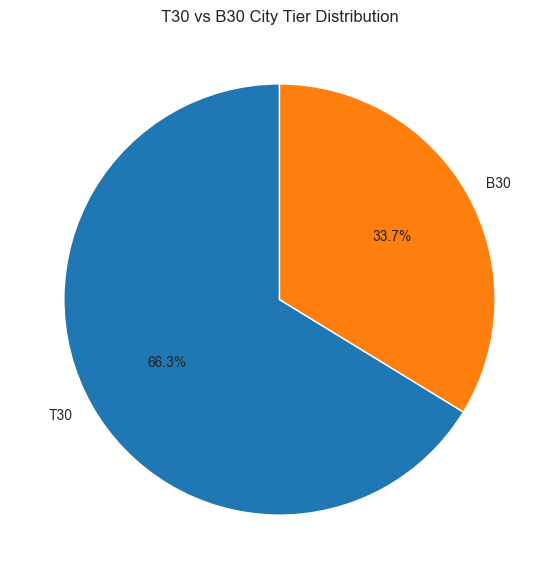

In [32]:
# Chart 9 - City Tier Distribution

city_data = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_data,
    labels=city_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig("../charts/city_tier_distribution.png", dpi=300)

plt.show()

## Insight 9

Investor participation is distributed across both T30 and B30 cities, showing that mutual fund investments extend beyond major metropolitan regions.

In [33]:
# Chart 10 - Folio Count Growth

folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [34]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

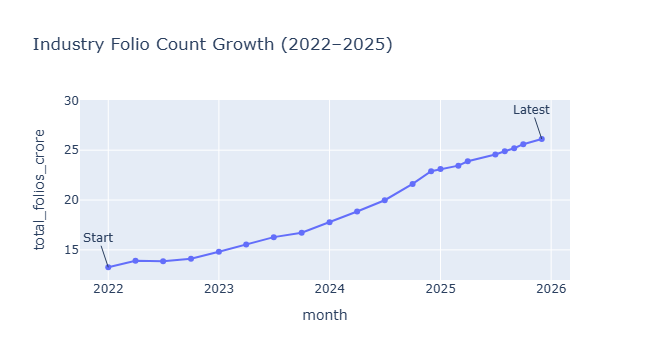

In [35]:
# Chart 10 - Folio Count Growth

folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Count Growth (2022–2025)"
)

# Starting point
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="Start",
    showarrow=True
)

# Ending point
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="Latest",
    showarrow=True
)

fig.write_html("../charts/folio_growth.html")

fig.show()

## Insight 10

The total number of mutual fund folios increased steadily throughout the analysis period, indicating continuous growth in investor participation and account creation.

In [36]:
# Chart 11 - NAV Correlation Matrix

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [37]:
# Create pivot table

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [38]:
# Select first 10 funds

pivot = pivot.iloc[:, :10]

pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [39]:
returns = pivot.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360


In [40]:
corr = returns.corr()

corr.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384


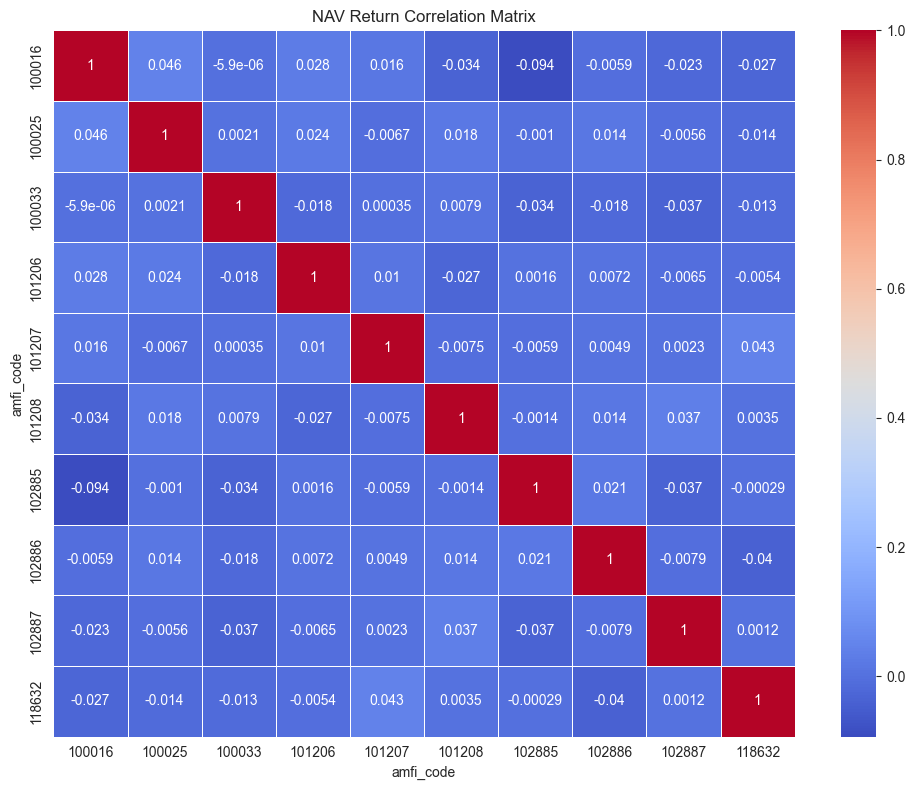

In [41]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig("../charts/nav_correlation.png", dpi=300)

plt.show()

## Insight 11

Most mutual fund schemes show positive correlations in daily returns, indicating that they tend to move together under similar market conditions. Some funds exhibit stronger relationships than others due to similar investment objectives.

In [42]:
# Chart 12 - Sector Allocation

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [43]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [44]:
# Chart 12 - Sector Allocation Donut Chart

sector_data = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

sector_data.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

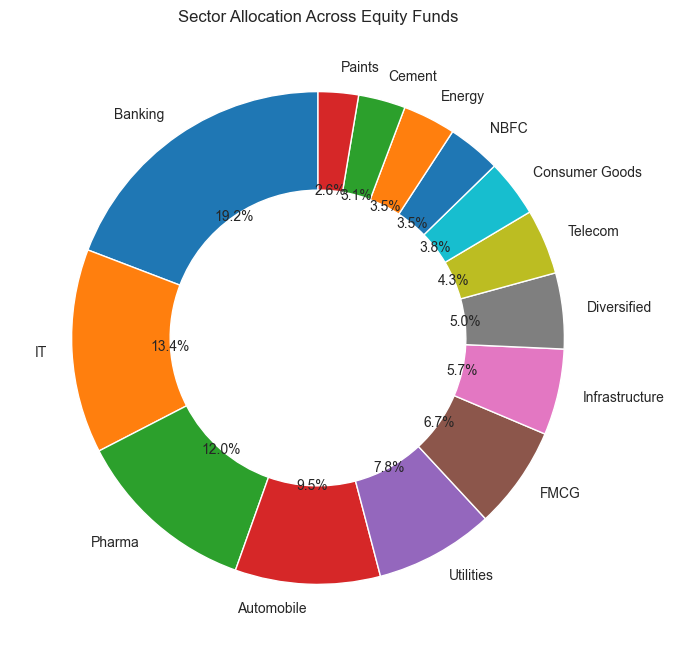

In [45]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../charts/sector_donut.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 12

Portfolio holdings are diversified across multiple sectors. Financials, Information Technology, and other major sectors account for a significant share of the overall portfolio allocation.

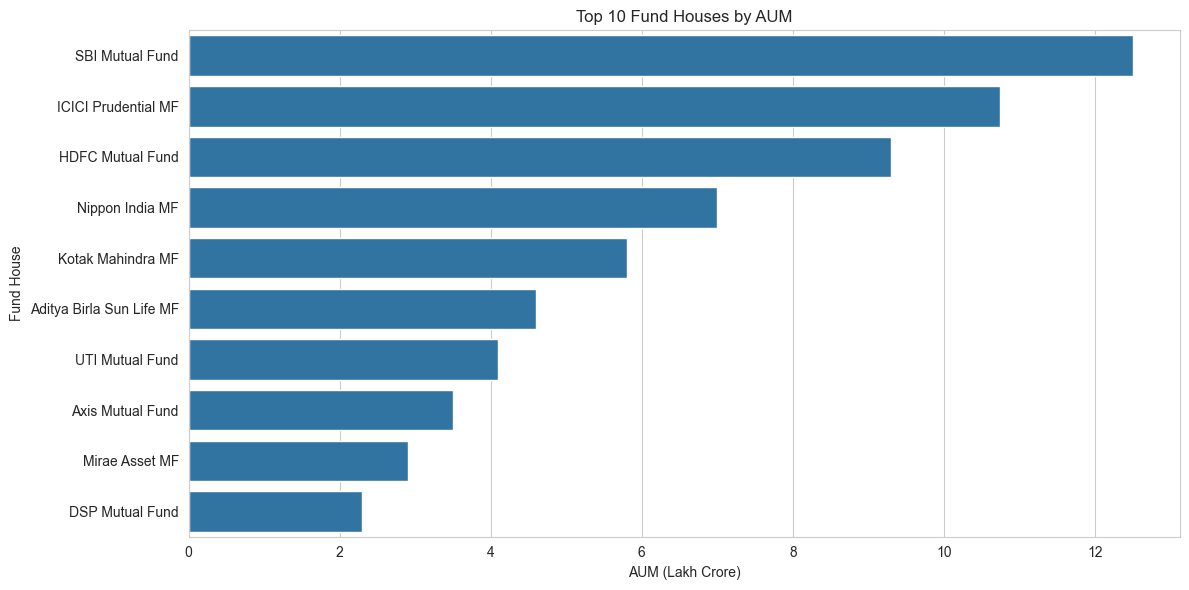

In [46]:
# Chart 13 - Top 10 Fund Houses by AUM

top_aum = (
    aum.groupby("fund_house")["aum_lakh_crore"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_aum.values,
    y=top_aum.index
)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("AUM (Lakh Crore)")
plt.ylabel("Fund House")

plt.tight_layout()

plt.savefig("../charts/top10_aum.png", dpi=300)

plt.show()

## Insight 13

The top fund houses manage a significant share of the industry's assets, with leading institutions dominating the mutual fund market.

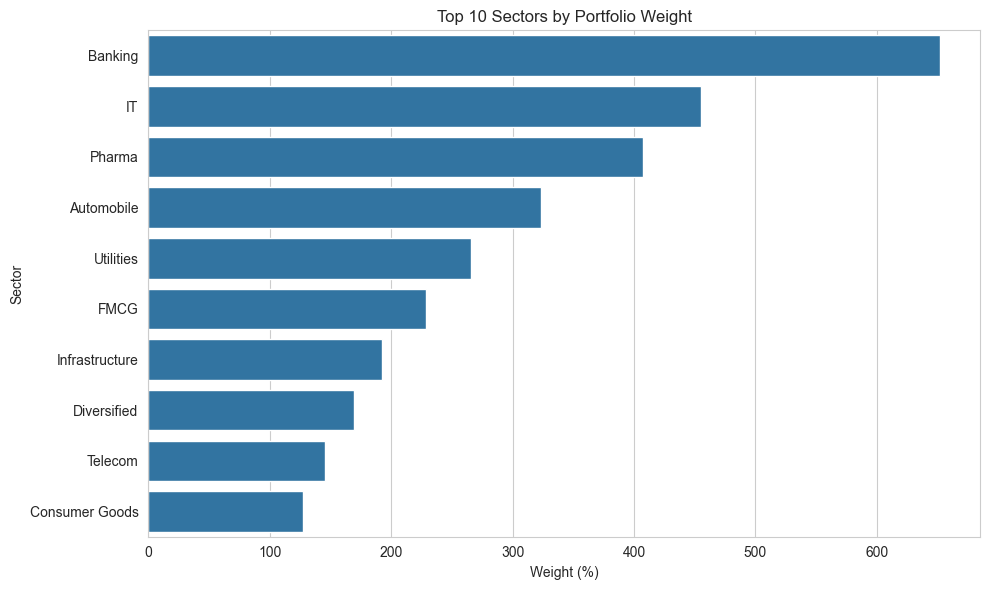

In [47]:
# Chart 14 - Top 10 Sectors

top_sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sector.values,
    y=top_sector.index
)

plt.title("Top 10 Sectors by Portfolio Weight")
plt.xlabel("Weight (%)")
plt.ylabel("Sector")

plt.tight_layout()

plt.savefig("../charts/top10_sectors.png", dpi=300)

plt.show()

## Insight 14

A few sectors account for the majority of portfolio allocation, indicating concentration in key industries while maintaining diversification across others.

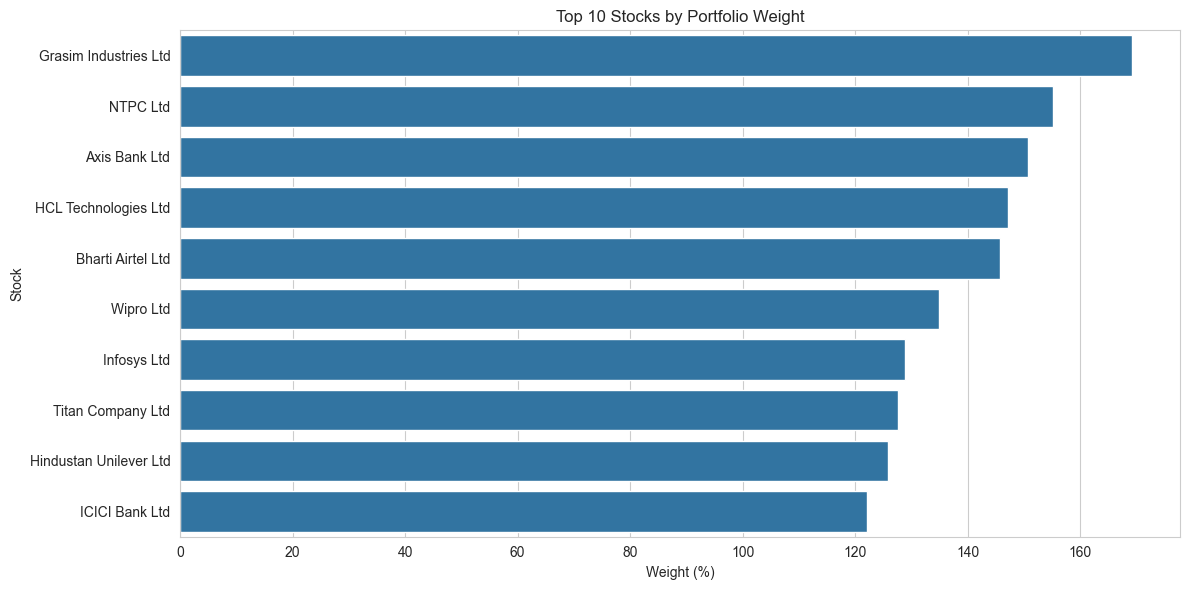

In [48]:
# Chart 15 - Top 10 Stocks

top_stocks = (
    portfolio.groupby("stock_name")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stocks.values,
    y=top_stocks.index
)

plt.title("Top 10 Stocks by Portfolio Weight")
plt.xlabel("Weight (%)")
plt.ylabel("Stock")

plt.tight_layout()

plt.savefig("../charts/top10_stocks.png", dpi=300)

plt.show()

## Insight 15

The highest-weighted stocks represent major portfolio holdings and contribute significantly to overall mutual fund performance.